In [1]:
# ===============================================================
# SUPPLY CHAIN ANALYTICS PROJECT
# Section 1 : Import Libraries
# ===============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("="*70)
print("Libraries Imported Successfully")
print("="*70)

Libraries Imported Successfully


In [5]:
# ===============================================================
# Upload Dataset
# ===============================================================

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("="*70)
print("Dataset Loaded Successfully")
print("="*70)

print("File Name :", file_name)

Saving supply_chain_data.csv to supply_chain_data (1).csv
Dataset Loaded Successfully
File Name : supply_chain_data (1).csv


In [3]:
# ===============================================================
# Dataset Overview
# ===============================================================

print("="*70)
print("Dataset Shape")
print("="*70)
print(df.shape)

print("\n")

print("="*70)
print("Column Names")
print("="*70)

for col in df.columns:
    print(col)

print("\n")

print("="*70)
print("Data Types")
print("="*70)

display(df.dtypes)

print("\n")

print("="*70)
print("First 10 Records")
print("="*70)

display(df.head(10))

Dataset Shape
(100, 24)


Column Names
Product type
SKU
Price
Availability
Number of products sold
Revenue generated
Customer demographics
Stock levels
Lead times
Order quantities
Shipping times
Shipping carriers
Shipping costs
Supplier name
Location
Lead time
Production volumes
Manufacturing lead time
Manufacturing costs
Inspection results
Defect rates
Transportation modes
Routes
Costs


Data Types


,0
Product type,object
SKU,object
Price,float64
Availability,int64
Number of products sold,int64
Revenue generated,float64
Customer demographics,object
Stock levels,int64
Lead times,int64
Order quantities,int64




First 10 Records


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,...,Bangalore,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,...,Kolkata,14,314,24,1.085069,Pending,1.000911,Sea,Route A,134.369097
7,cosmetics,SKU7,42.958384,59,426,8496.103813,Female,93,17,11,...,Bangalore,22,564,1,99.466109,Fail,0.398177,Road,Route C,802.056312
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,...,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134
9,skincare,SKU9,64.015733,35,980,4971.145988,Unknown,14,27,83,...,Chennai,29,963,23,47.957602,Pending,3.844614,Rail,Route B,995.929461


In [ ]:
# ===============================================================
# Missing Values
# ===============================================================

print("="*70)
print("Missing Values")
print("="*70)

display(df.isnull().sum())

print("\n")

print("="*70)
print("Duplicate Records")
print("="*70)

print(df.duplicated().sum())

Missing Values


,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0




Duplicate Records
0


In [ ]:
# ===============================================================
# Data Cleaning
# ===============================================================

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing values

for col in df.columns:

    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")

    else:
        df[col] = df[col].fillna(df[col].median())

print("="*70)
print("Cleaning Completed")
print("="*70)

print(df.shape)

Cleaning Completed
(100, 24)


In [ ]:
# ===============================================================
# Feature Engineering
# ===============================================================

# Profit Estimation

df["Estimated Profit"] = (
    df["Revenue generated"] -
    df["Manufacturing costs"] -
    df["Shipping costs"]
)

# Profit Margin

df["Profit Margin"] = (
    df["Estimated Profit"] /
    df["Revenue generated"]
) * 100

# Inventory Status

df["Inventory Status"] = np.where(
    df["Availability"] < 100,
    "Low Stock",
    "In Stock"
)

print("="*70)
print("Feature Engineering Completed")
print("="*70)

display(df.head())

Feature Engineering Completed


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Estimated Profit,Profit Margin,Inventory Status
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,29,46.279879,Pending,0.226410,Road,Route B,187.752075,8612.760341,99.431581,Low Stock
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,30,33.616769,Pending,4.854068,Road,Route B,503.065579,7417.566722,99.419194,Low Stock
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,27,30.688019,Pending,4.580593,Air,Route C,141.920282,9539.007127,99.595495,Low Stock
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,7729.482116,99.519054,Low Stock
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,3,92.065161,Fail,3.145580,Air,Route A,923.440632,2590.549443,96.428233,Low Stock


In [ ]:
# ===============================================================
# Dataset Statistics
# ===============================================================

display(df.describe(include="all"))

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs,Estimated Profit,Profit Margin,Inventory Status
count,100,100,100.000000,100.000000,100.000000,100.000000,100,100.000000,100.000000,100.000000,...,100.00000,100.000000,100,100.000000,100,100,100.000000,100.000000,100.000000,100
unique,3,100,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,...,NaN,NaN,3,NaN,4,3,NaN,NaN,NaN,2
top,skincare,SKU0,NaN,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,...,NaN,NaN,Pending,NaN,Road,Route A,NaN,NaN,NaN,Low Stock
freq,40,1,NaN,NaN,NaN,NaN,31,NaN,NaN,NaN,...,NaN,NaN,41,NaN,29,43,NaN,NaN,NaN,99
mean,NaN,NaN,49.462461,48.400000,460.990000,5776.048187,NaN,47.770000,15.960000,49.220000,...,14.77000,47.266693,NaN,2.277158,NaN,NaN,529.245782,5723.233345,98.622649,NaN
std,NaN,NaN,31.168193,30.743317,303.780074,2732.841744,NaN,31.369372,8.785801,26.784429,...,8.91243,28.982841,NaN,1.461366,NaN,NaN,258.301696,2739.385370,1.387700,NaN
min,NaN,NaN,1.699976,1.000000,8.000000,1061.618523,NaN,0.000000,1.000000,1.000000,...,1.00000,1.085069,NaN,0.018608,NaN,NaN,103.916248,1052.424038,93.813937,NaN
25%,NaN,NaN,19.597823,22.750000,184.250000,2812.847151,NaN,16.750000,8.000000,26.000000,...,7.00000,22.983299,NaN,1.009650,NaN,NaN,318.778455,2751.791865,98.170341,NaN
50%,NaN,NaN,51.239831,43.500000,392.500000,6006.352023,NaN,47.500000,17.000000,52.000000,...,14.00000,45.905622,NaN,2.141863,NaN,NaN,520.430444,5958.072985,99.092837,NaN
75%,NaN,NaN,77.198228,75.000000,704.250000,8253.976921,NaN,73.000000,24.000000,71.250000,...,23.00000,68.621026,NaN,3.563995,NaN,NaN,763.078231,8178.860299,99.486304,NaN


In [ ]:
# ===============================================================
# Export Clean Dataset
# ===============================================================

df.to_csv("Supply_Cleaned.csv", index=False)

print("="*70)
print("Supply_Cleaned.csv Saved Successfully")
print("="*70)

Supply_Cleaned.csv Saved Successfully


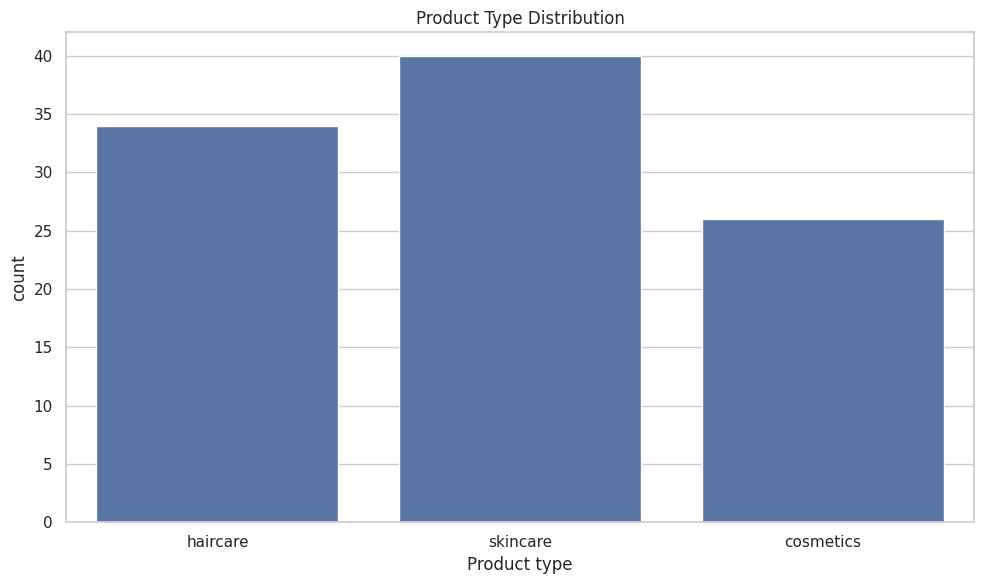

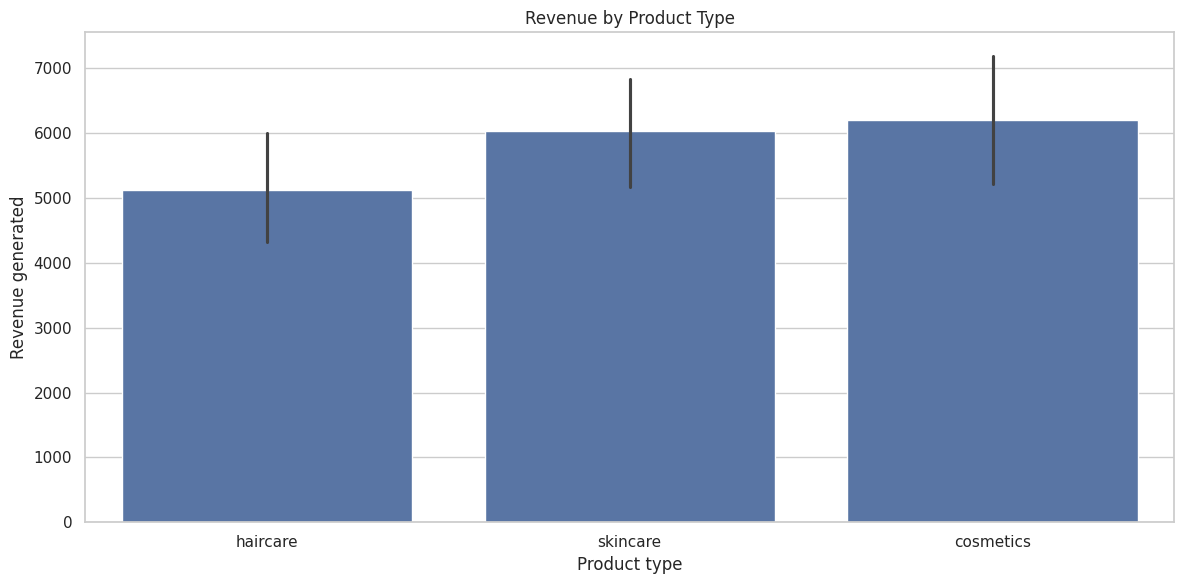

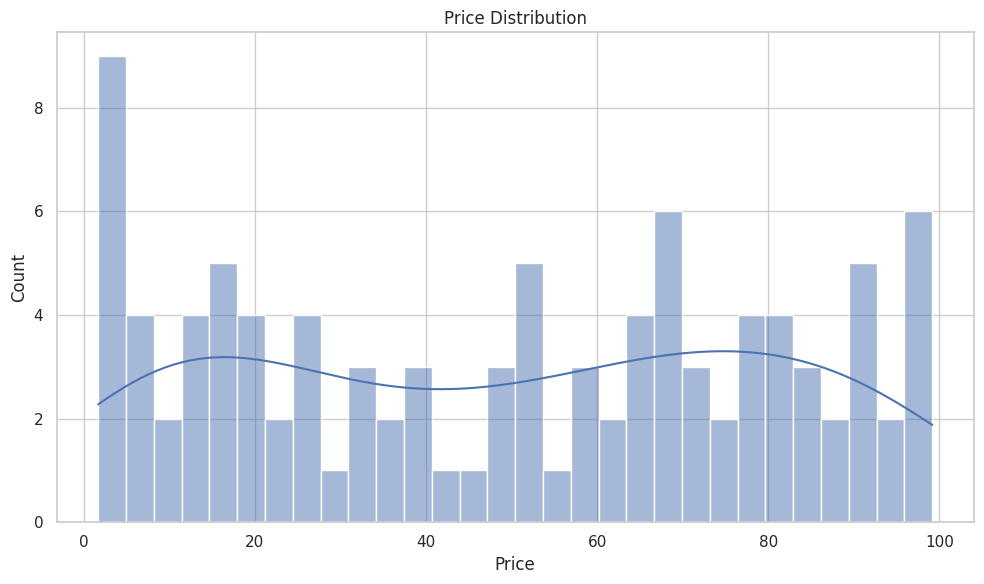

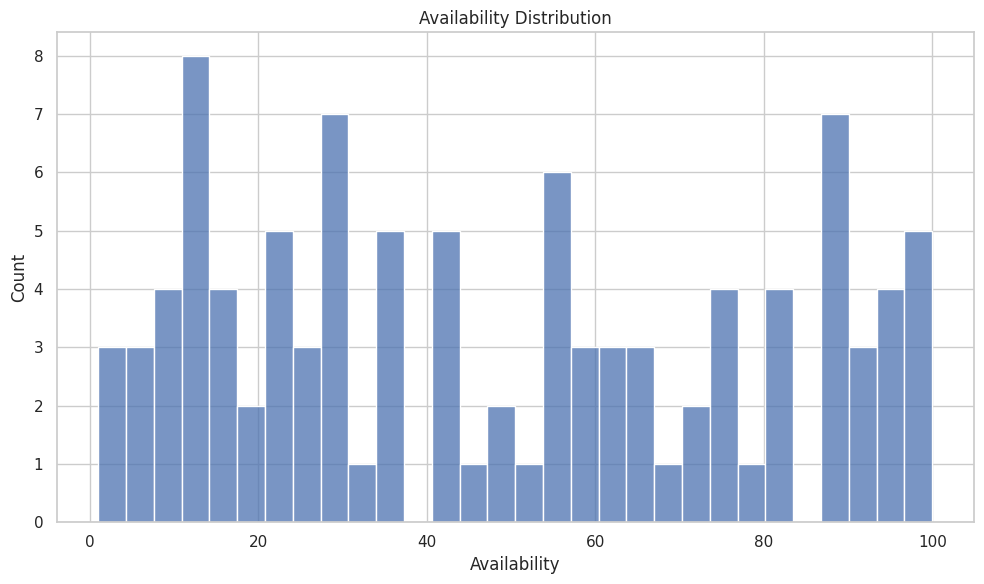

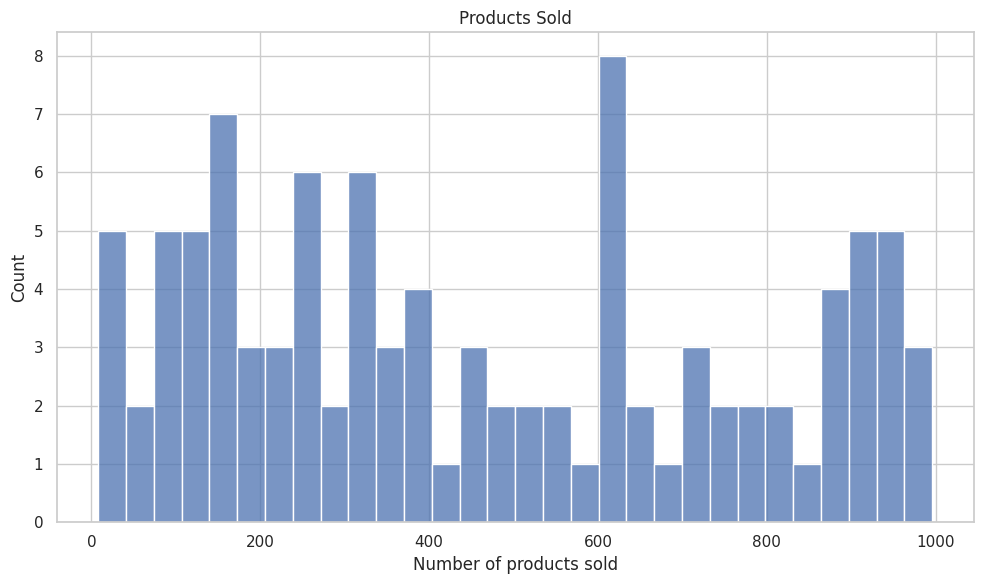

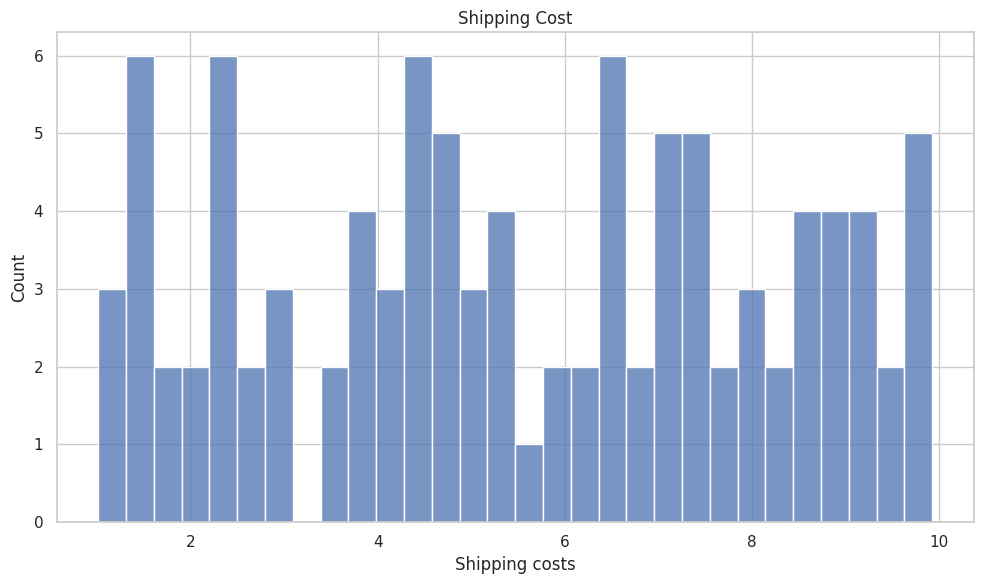

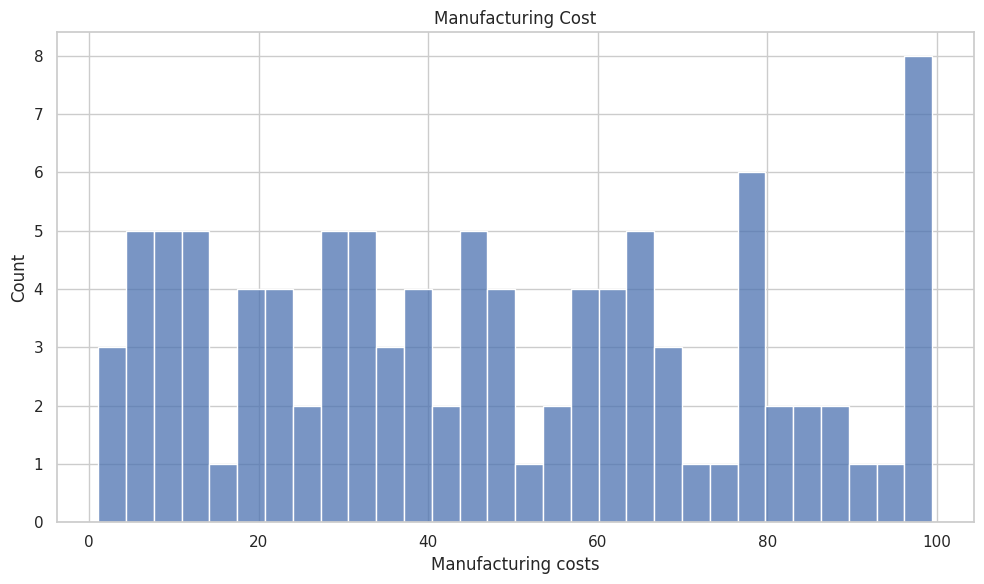

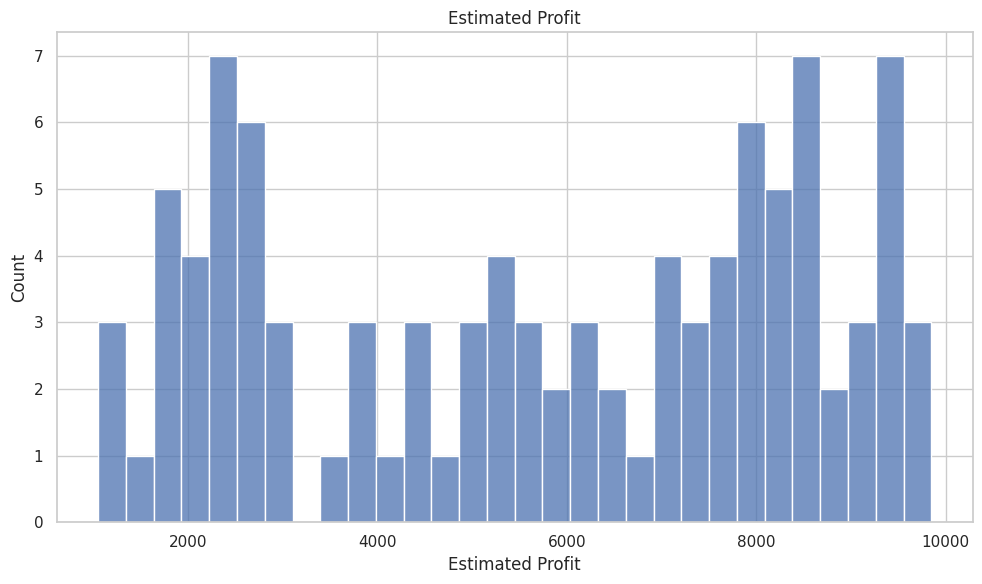

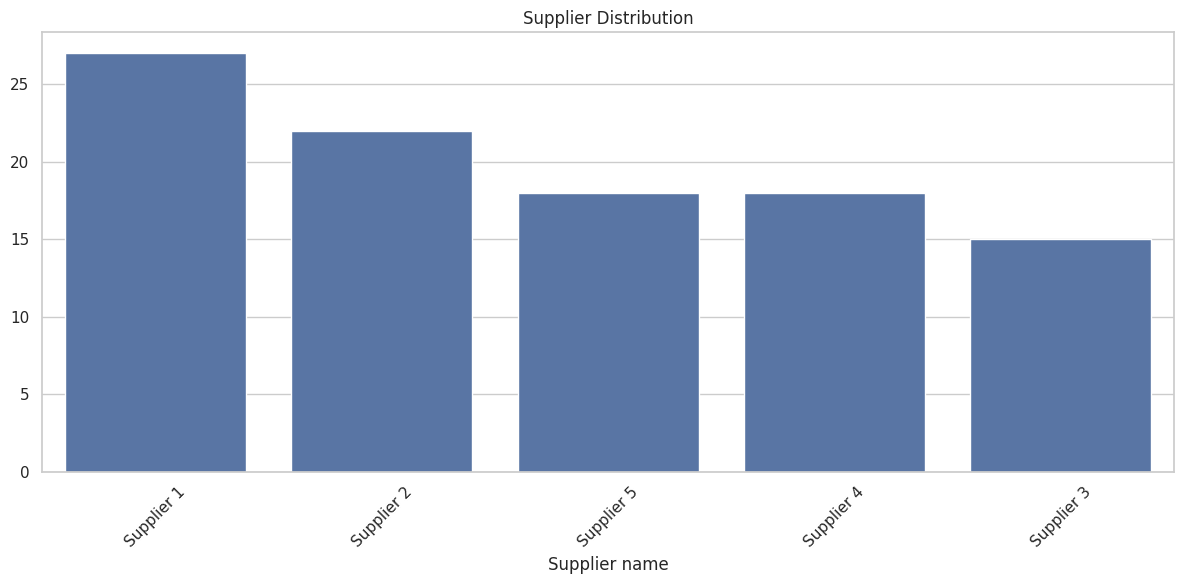

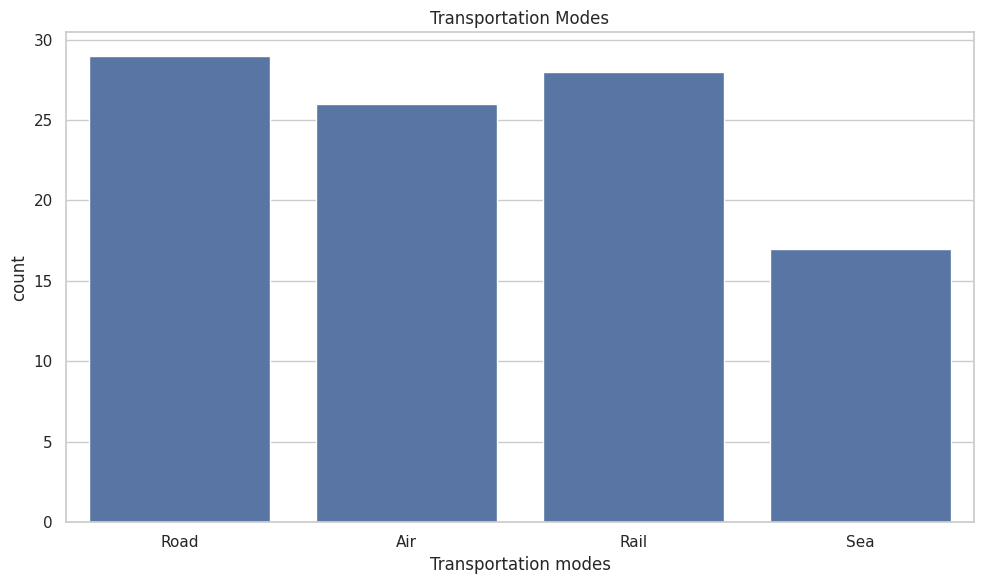

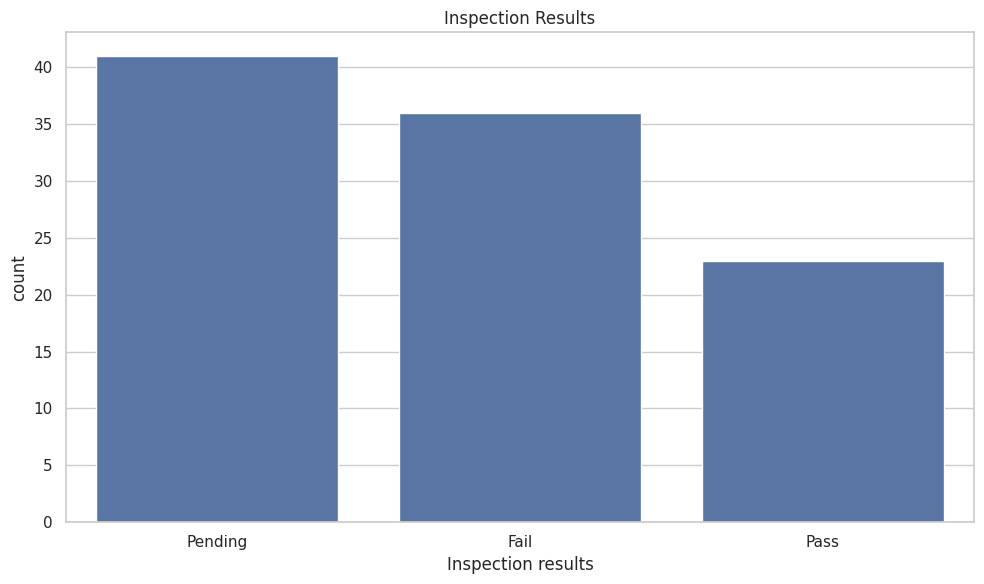

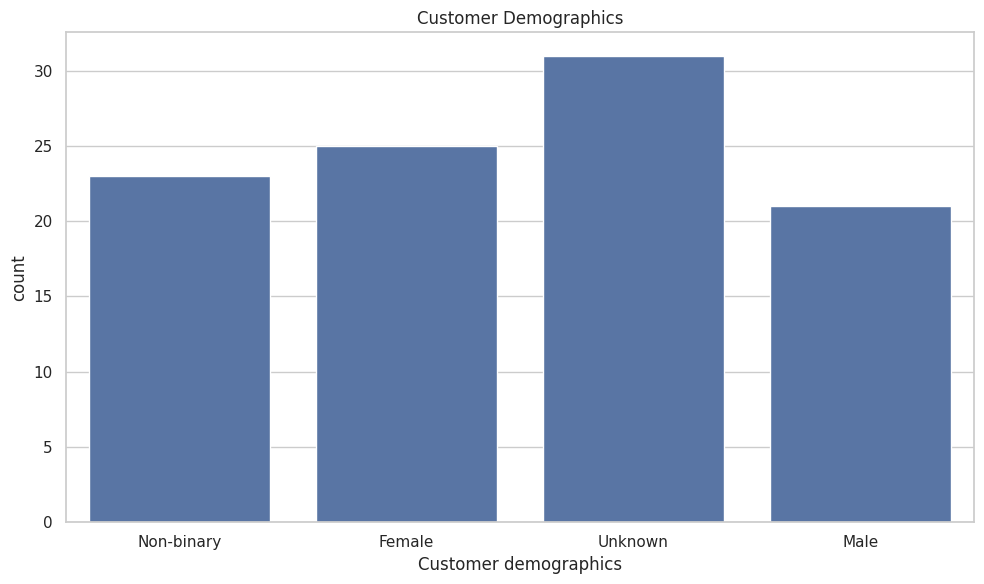

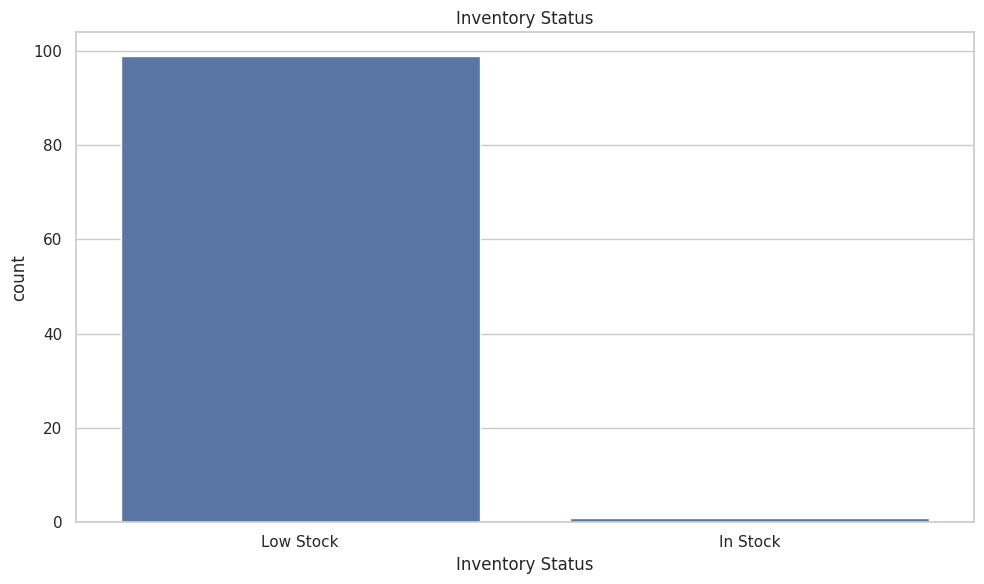

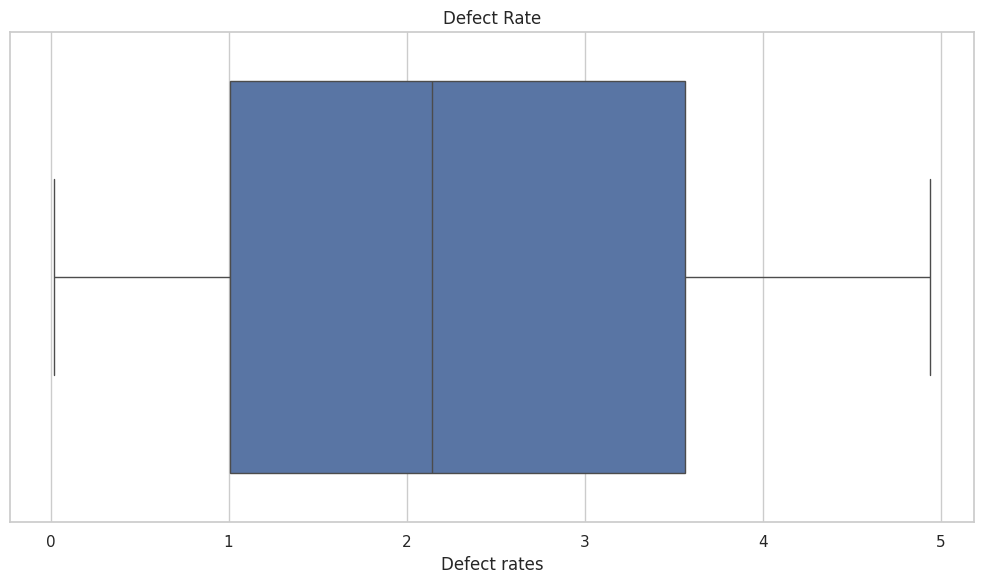

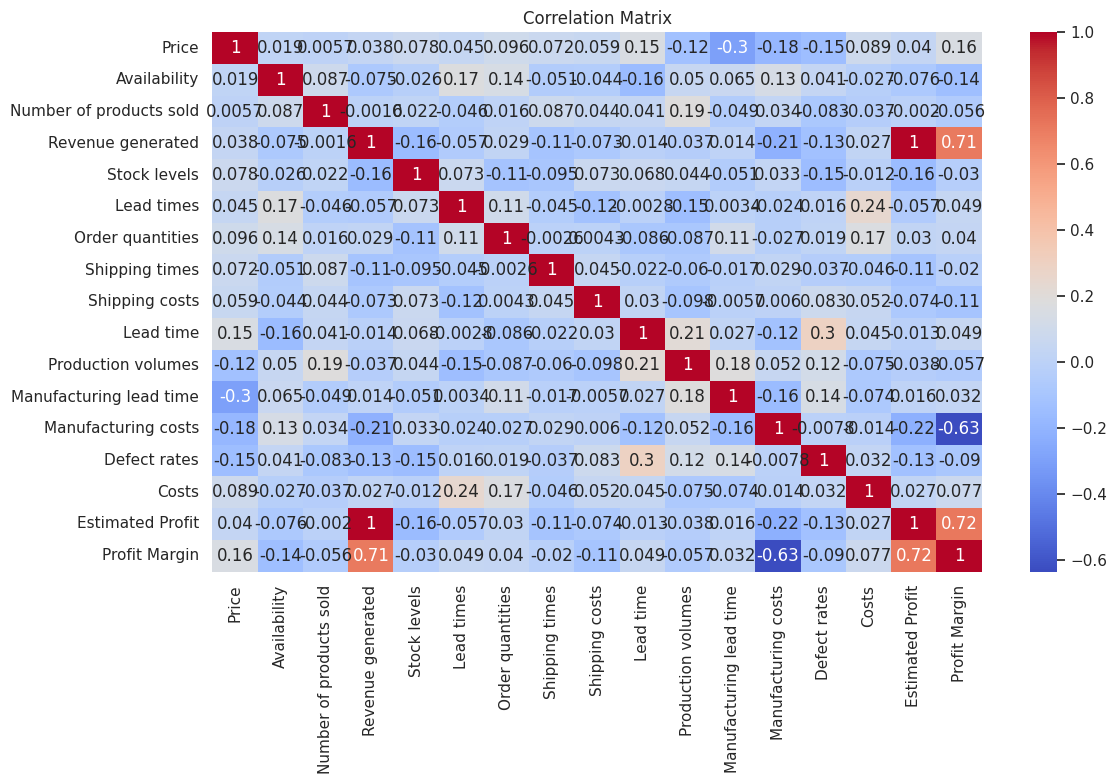

15 Professional Charts Created


In [ ]:
# ===============================================================
# SECTION 2 : SUPPLY CHAIN VISUALIZATIONS
# ===============================================================

import os

os.makedirs("visuals", exist_ok=True)

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

def save_plot(name):
    plt.tight_layout()
    plt.savefig(f"visuals/{name}.png",dpi=300)
    plt.show()
    plt.close()

# ------------------------------------------------
# Product Type
# ------------------------------------------------

plt.figure()

sns.countplot(data=df,x="Product type")

plt.title("Product Type Distribution")

save_plot("01_product_type")


# ------------------------------------------------
# Revenue
# ------------------------------------------------

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x="Product type",
    y="Revenue generated"
)

plt.title("Revenue by Product Type")

save_plot("02_revenue")


# ------------------------------------------------
# Price
# ------------------------------------------------

plt.figure()

sns.histplot(df["Price"],bins=30,kde=True)

plt.title("Price Distribution")

save_plot("03_price")


# ------------------------------------------------
# Availability
# ------------------------------------------------

plt.figure()

sns.histplot(df["Availability"],bins=30)

plt.title("Availability Distribution")

save_plot("04_availability")


# ------------------------------------------------
# Products Sold
# ------------------------------------------------

plt.figure()

sns.histplot(df["Number of products sold"],bins=30)

plt.title("Products Sold")

save_plot("05_products_sold")


# ------------------------------------------------
# Shipping Cost
# ------------------------------------------------

plt.figure()

sns.histplot(df["Shipping costs"],bins=30)

plt.title("Shipping Cost")

save_plot("06_shipping_cost")


# ------------------------------------------------
# Manufacturing Cost
# ------------------------------------------------

plt.figure()

sns.histplot(df["Manufacturing costs"],bins=30)

plt.title("Manufacturing Cost")

save_plot("07_manufacturing_cost")


# ------------------------------------------------
# Profit
# ------------------------------------------------

plt.figure()

sns.histplot(df["Estimated Profit"],bins=30)

plt.title("Estimated Profit")

save_plot("08_profit")


# ------------------------------------------------
# Supplier
# ------------------------------------------------

plt.figure(figsize=(12,6))

supplier=df["Supplier name"].value_counts()

sns.barplot(
    x=supplier.index,
    y=supplier.values
)

plt.xticks(rotation=45)

plt.title("Supplier Distribution")

save_plot("09_supplier")


# ------------------------------------------------
# Transportation
# ------------------------------------------------

plt.figure()

sns.countplot(
    data=df,
    x="Transportation modes"
)

plt.title("Transportation Modes")

save_plot("10_transport")


# ------------------------------------------------
# Inspection
# ------------------------------------------------

plt.figure()

sns.countplot(
    data=df,
    x="Inspection results"
)

plt.title("Inspection Results")

save_plot("11_inspection")


# ------------------------------------------------
# Customer
# ------------------------------------------------

plt.figure()

sns.countplot(
    data=df,
    x="Customer demographics"
)

plt.title("Customer Demographics")

save_plot("12_customer")


# ------------------------------------------------
# Inventory
# ------------------------------------------------

plt.figure()

sns.countplot(
    data=df,
    x="Inventory Status"
)

plt.title("Inventory Status")

save_plot("13_inventory")


# ------------------------------------------------
# Defect Rate
# ------------------------------------------------

plt.figure()

sns.boxplot(
    x=df["Defect rates"]
)

plt.title("Defect Rate")

save_plot("14_defect")


# ------------------------------------------------
# Correlation
# ------------------------------------------------

plt.figure(figsize=(12,8))

corr=df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,annot=True,cmap="coolwarm")

plt.title("Correlation Matrix")

save_plot("15_heatmap")

print("="*60)
print("15 Professional Charts Created")
print("="*60)

In [ ]:
# ===============================================================
# SECTION 3 : EXECUTIVE BUSINESS KPI REPORT
# ===============================================================

print("="*80)
print("SUPPLY CHAIN EXECUTIVE BUSINESS REPORT")
print("="*80)

# ---------------------------------------------------
# Overall KPIs
# ---------------------------------------------------

total_products = len(df)
total_revenue = round(df["Revenue generated"].sum(),2)
total_profit = round(df["Estimated Profit"].sum(),2)
avg_profit = round(df["Estimated Profit"].mean(),2)
avg_price = round(df["Price"].mean(),2)
avg_shipping = round(df["Shipping costs"].mean(),2)
avg_manufacturing = round(df["Manufacturing costs"].mean(),2)

print(f"Total Products              : {total_products}")
print(f"Total Revenue               : ${total_revenue}")
print(f"Estimated Profit            : ${total_profit}")
print(f"Average Profit              : ${avg_profit}")
print(f"Average Product Price       : ${avg_price}")
print(f"Average Shipping Cost       : ${avg_shipping}")
print(f"Average Manufacturing Cost  : ${avg_manufacturing}")

print("\n")

# ---------------------------------------------------
# Revenue by Product
# ---------------------------------------------------

print("="*80)
print("REVENUE BY PRODUCT TYPE")
print("="*80)

revenue_product = (
    df.groupby("Product type")["Revenue generated"]
      .sum()
      .sort_values(ascending=False)
)

display(revenue_product)

print("\n")

# ---------------------------------------------------
# Profit by Product
# ---------------------------------------------------

print("="*80)
print("PROFIT BY PRODUCT TYPE")
print("="*80)

profit_product = (
    df.groupby("Product type")["Estimated Profit"]
      .sum()
      .sort_values(ascending=False)
)

display(profit_product)

print("\n")

# ---------------------------------------------------
# Top Suppliers
# ---------------------------------------------------

print("="*80)
print("TOP SUPPLIERS")
print("="*80)

supplier_revenue = (
    df.groupby("Supplier name")["Revenue generated"]
      .sum()
      .sort_values(ascending=False)
)

display(supplier_revenue)

print("\n")

# ---------------------------------------------------
# Transportation Modes
# ---------------------------------------------------

print("="*80)
print("TRANSPORTATION MODES")
print("="*80)

display(df["Transportation modes"].value_counts())

print("\n")

# ---------------------------------------------------
# Inventory Status
# ---------------------------------------------------

print("="*80)
print("INVENTORY STATUS")
print("="*80)

display(df["Inventory Status"].value_counts())

print("\n")

# ---------------------------------------------------
# Customer Demographics
# ---------------------------------------------------

print("="*80)
print("CUSTOMER DEMOGRAPHICS")
print("="*80)

display(df["Customer demographics"].value_counts())

print("\n")

# ---------------------------------------------------
# Inspection Results
# ---------------------------------------------------

print("="*80)
print("INSPECTION RESULTS")
print("="*80)

display(df["Inspection results"].value_counts())

print("\n")

# ---------------------------------------------------
# Defect Rates
# ---------------------------------------------------

print("="*80)
print("DEFECT RATE SUMMARY")
print("="*80)

print(df["Defect rates"].describe())

print("\n")

# ---------------------------------------------------
# Top Revenue Products
# ---------------------------------------------------

print("="*80)
print("TOP 10 PRODUCTS BY REVENUE")
print("="*80)

display(
    df.sort_values(
        by="Revenue generated",
        ascending=False
    )[[
        "SKU",
        "Product type",
        "Revenue generated",
        "Estimated Profit",
        "Supplier name"
    ]].head(10)
)

print("\n")

# ---------------------------------------------------
# Most Expensive Products
# ---------------------------------------------------

print("="*80)
print("TOP 10 MOST EXPENSIVE PRODUCTS")
print("="*80)

display(
    df.sort_values(
        by="Price",
        ascending=False
    )[[
        "SKU",
        "Product type",
        "Price",
        "Revenue generated"
    ]].head(10)
)

print("\n")

print("="*80)
print("EXECUTIVE REPORT GENERATED SUCCESSFULLY")
print("="*80)

SUPPLY CHAIN EXECUTIVE BUSINESS REPORT
Total Products              : 100
Total Revenue               : $577604.82
Estimated Profit            : $572323.33
Average Profit              : $5723.23
Average Product Price       : $49.46
Average Shipping Cost       : $5.55
Average Manufacturing Cost  : $47.27


REVENUE BY PRODUCT TYPE


,Revenue generated
Product type,
skincare,241628.162133
haircare,174455.390605
cosmetics,161521.265999




PROFIT BY PRODUCT TYPE


,Estimated Profit
Product type,
skincare,239472.048328
haircare,172606.955095
cosmetics,160244.331084




TOP SUPPLIERS


...



DEFECT RATE SUMMARY
count    100.000000
mean       2.277158
std        1.461366
min        0.018608
25%        1.009650
50%        2.141863
75%        3.563995
max        4.939255
Name: Defect rates, dtype: float64


TOP 10 PRODUCTS BY REVENUE


,SKU,Product type,Revenue generated,Estimated Profit,Supplier name
51,SKU51,haircare,9866.465458,9847.492129,Supplier 5
38,SKU38,cosmetics,9692.318040,9677.151415,Supplier 5
31,SKU31,skincare,9655.135103,9592.204296,Supplier 3
90,SKU90,skincare,9592.633570,9499.283176,Supplier 3
2,SKU2,haircare,9577.749626,9539.007127,Supplier 1
32,SKU32,skincare,9571.550487,9535.258915,Supplier 3
67,SKU67,skincare,9473.798033,9457.592345,Supplier 1
88,SKU88,cosmetics,9444.742033,9372.755861,Supplier 2
52,SKU52,skincare,9435.762609,9417.964708,Supplier 1
18,SKU18,haircare,9364.673505,9333.226300,Supplier 2




TOP 10 MOST EXPENSIVE PRODUCTS


,SKU,Product type,Price,Revenue generated
14,SKU14,skincare,99.171329,8653.570926
41,SKU41,skincare,99.113292,5521.205259
52,SKU52,skincare,98.031830,9435.762609
89,SKU89,cosmetics,97.760086,5924.682567
26,SKU26,haircare,97.446947,3716.493326
20,SKU20,skincare,96.341072,8128.027697
47,SKU47,skincare,95.712136,7089.474250
75,SKU75,skincare,92.996884,1889.073590
27,SKU27,cosmetics,92.557361,2686.457224
80,SKU80,skincare,91.128318,8651.672683




EXECUTIVE REPORT GENERATED SUCCESSFULLY


In [ ]:
# ===============================================================
# EXPORT REPORTS
# ===============================================================

import os

os.makedirs("reports", exist_ok=True)

revenue_product.to_csv("reports/revenue_by_product.csv")
profit_product.to_csv("reports/profit_by_product.csv")
supplier_revenue.to_csv("reports/supplier_revenue.csv")

df.to_csv("reports/final_supply_chain_dataset.csv", index=False)

print("="*70)
print("REPORTS EXPORTED SUCCESSFULLY")
print("="*70)

REPORTS EXPORTED SUCCESSFULLY
